In [2]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from scipy import stats

In [3]:
df = pd.read_csv("C:/Users/DELL/Downloads/Credit Card Defaulter Prediction.csv")

In [4]:
df.head()

,ID,LIMIT_BAL,SEX,EDUCATION,MARRIAGE,AGE,PAY_0,PAY_2,PAY_3,PAY_4,...,BILL_AMT4,BILL_AMT5,BILL_AMT6,PAY_AMT1,PAY_AMT2,PAY_AMT3,PAY_AMT4,PAY_AMT5,PAY_AMT6,default
0,1,20000,F,University,Married,24,2,2,-1,-1,...,0,0,0,0,689,0,0,0,0,Y
1,2,120000,F,University,Single,26,-1,2,0,0,...,3272,3455,3261,0,1000,1000,1000,0,2000,Y
2,3,90000,F,University,Single,34,0,0,0,0,...,14331,14948,15549,1518,1500,1000,1000,1000,5000,N
3,4,50000,F,University,Married,37,0,0,0,0,...,28314,28959,29547,2000,2019,1200,1100,1069,1000,N
4,5,50000,M,University,Married,57,-1,0,-1,0,...,20940,19146,19131,2000,36681,10000,9000,689,679,N


In [5]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 30000 entries, 0 to 29999
Data columns (total 25 columns):
 #   Column     Non-Null Count  Dtype
---  ------     --------------  -----
 0   ID         30000 non-null  int64
 1   LIMIT_BAL  30000 non-null  int64
 2   SEX        30000 non-null  str  
 3   EDUCATION  30000 non-null  str  
 4   MARRIAGE   30000 non-null  str  
 5   AGE        30000 non-null  int64
 6   PAY_0      30000 non-null  int64
 7   PAY_2      30000 non-null  int64
 8   PAY_3      30000 non-null  int64
 9   PAY_4      30000 non-null  int64
 10  PAY_5      30000 non-null  int64
 11  PAY_6      30000 non-null  int64
 12  BILL_AMT1  30000 non-null  int64
 13  BILL_AMT2  30000 non-null  int64
 14  BILL_AMT3  30000 non-null  int64
 15  BILL_AMT4  30000 non-null  int64
 16  BILL_AMT5  30000 non-null  int64
 17  BILL_AMT6  30000 non-null  int64
 18  PAY_AMT1   30000 non-null  int64
 19  PAY_AMT2   30000 non-null  int64
 20  PAY_AMT3   30000 non-null  int64
 21  PAY_AMT4   30000 non-nu

In [6]:
df.describe()

,ID,LIMIT_BAL,AGE,PAY_0,PAY_2,PAY_3,PAY_4,PAY_5,PAY_6,BILL_AMT1,...,BILL_AMT3,BILL_AMT4,BILL_AMT5,BILL_AMT6,PAY_AMT1,PAY_AMT2,PAY_AMT3,PAY_AMT4,PAY_AMT5,PAY_AMT6
count,30000.000000,30000.000000,30000.000000,30000.000000,30000.000000,30000.000000,30000.000000,30000.000000,30000.000000,30000.000000,...,3.000000e+04,30000.000000,30000.000000,30000.000000,30000.000000,3.000000e+04,30000.00000,30000.000000,30000.000000,30000.000000
mean,15000.500000,167484.322667,35.485500,-0.016700,-0.133767,-0.166200,-0.220667,-0.266200,-0.291100,51223.330900,...,4.701315e+04,43262.948967,40311.400967,38871.760400,5663.580500,5.921163e+03,5225.68150,4826.076867,4799.387633,5215.502567
std,8660.398374,129747.661567,9.217904,1.123802,1.197186,1.196868,1.169139,1.133187,1.149988,73635.860576,...,6.934939e+04,64332.856134,60797.155770,59554.107537,16563.280354,2.304087e+04,17606.96147,15666.159744,15278.305679,17777.465775
min,1.000000,10000.000000,21.000000,-2.000000,-2.000000,-2.000000,-2.000000,-2.000000,-2.000000,-165580.000000,...,-1.572640e+05,-170000.000000,-81334.000000,-339603.000000,0.000000,0.000000e+00,0.00000,0.000000,0.000000,0.000000
25%,7500.750000,50000.000000,28.000000,-1.000000,-1.000000,-1.000000,-1.000000,-1.000000,-1.000000,3558.750000,...,2.666250e+03,2326.750000,1763.000000,1256.000000,1000.000000,8.330000e+02,390.00000,296.000000,252.500000,117.750000
50%,15000.500000,140000.000000,34.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,22381.500000,...,2.008850e+04,19052.000000,18104.500000,17071.000000,2100.000000,2.009000e+03,1800.00000,1500.000000,1500.000000,1500.000000
75%,22500.250000,240000.000000,41.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,67091.000000,...,6.016475e+04,54506.000000,50190.500000,49198.250000,5006.000000,5.000000e+03,4505.00000,4013.250000,4031.500000,4000.000000
max,30000.000000,1000000.000000,79.000000,8.000000,8.000000,8.000000,8.000000,8.000000,8.000000,964511.000000,...,1.664089e+06,891586.000000,927171.000000,961664.000000,873552.000000,1.684259e+06,896040.00000,621000.000000,426529.000000,528666.000000


In [7]:
df.shape

(30000, 25)

In [8]:
df.columns

Index(['ID', 'LIMIT_BAL', 'SEX', 'EDUCATION', 'MARRIAGE', 'AGE', 'PAY_0',
       'PAY_2', 'PAY_3', 'PAY_4', 'PAY_5', 'PAY_6', 'BILL_AMT1', 'BILL_AMT2',
       'BILL_AMT3', 'BILL_AMT4', 'BILL_AMT5', 'BILL_AMT6', 'PAY_AMT1',
       'PAY_AMT2', 'PAY_AMT3', 'PAY_AMT4', 'PAY_AMT5', 'PAY_AMT6', 'default '],
      dtype='str')

In [9]:
df.columns = df.columns.str.strip()

In [10]:
df.isnull().sum()

ID           0
LIMIT_BAL    0
SEX          0
EDUCATION    0
MARRIAGE     0
AGE          0
PAY_0        0
PAY_2        0
PAY_3        0
PAY_4        0
PAY_5        0
PAY_6        0
BILL_AMT1    0
BILL_AMT2    0
BILL_AMT3    0
BILL_AMT4    0
BILL_AMT5    0
BILL_AMT6    0
PAY_AMT1     0
PAY_AMT2     0
PAY_AMT3     0
PAY_AMT4     0
PAY_AMT5     0
PAY_AMT6     0
default      0
dtype: int64

In [11]:
df.duplicated().sum()

np.int64(0)

In [12]:
# Default Rate

In [13]:
df['default'].value_counts(normalize = True) * 100

default
N    77.88
Y    22.12
Name: proportion, dtype: float64

C:\Users\DELL\AppData\Local\Temp\ipykernel_33388\1075442126.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x='default', data=df, order=['N','Y'], palette=['#4C72B0','#DD8452'])


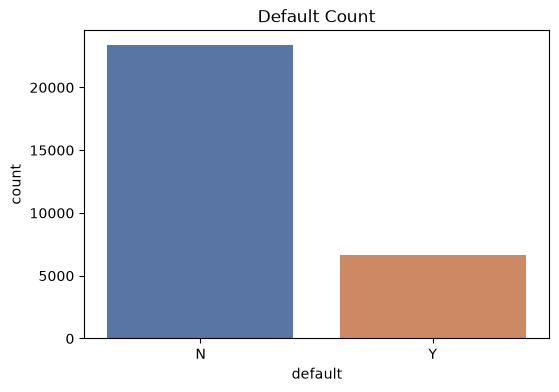

In [14]:
plt.figure(figsize=(6,4))
sns.countplot(x='default', data=df, order=['N','Y'], palette=['#4C72B0','#DD8452'])
plt.title('Default Count')
plt.show()

- About 22% of clients defaulted , 78% did not -- from this we can say that the data is imbalanced

### 1. SEX

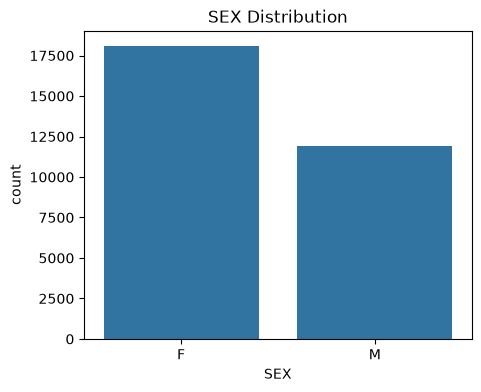

In [15]:
plt.figure(figsize=(5,4))
sns.countplot(x='SEX', data=df)
plt.title('SEX Distribution')
plt.show()

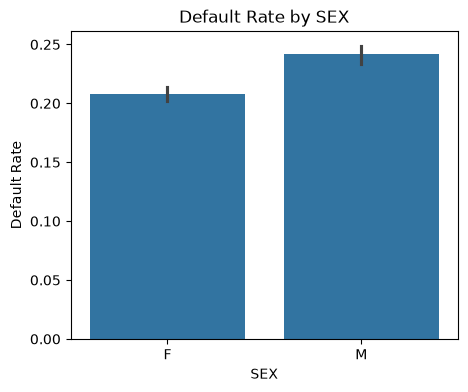

In [16]:
plt.figure(figsize=(5,4))
sns.barplot(x='SEX', y='default', data=df.assign(default=(df['default']=='Y').astype(int)))
plt.title('Default Rate by SEX')
plt.ylabel('Default Rate')
plt.show()

### 2. EDUCATION

In [17]:
df['EDUCATION'].value_counts(normalize=True) * 100

EDUCATION
University         46.766667
Graduate school    35.283333
High School        16.390000
Unknown             1.103333
Others              0.410000
0                   0.046667
Name: proportion, dtype: float64

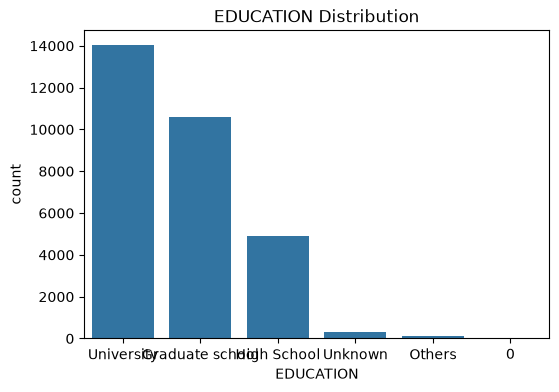

In [18]:
plt.figure(figsize=(6,4))
sns.countplot(x='EDUCATION', data=df, order=df['EDUCATION'].value_counts().index)
plt.title('EDUCATION Distribution')
plt.show()

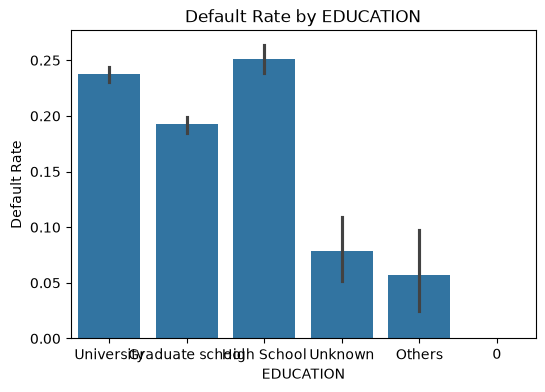

In [19]:
plt.figure(figsize=(6,4))
sns.barplot(x='EDUCATION', y='default', data=df.assign(default=(df['default']=='Y').astype(int)))
plt.title('Default Rate by EDUCATION')
plt.ylabel('Default Rate')
plt.show()

### 3. MARRIAGE

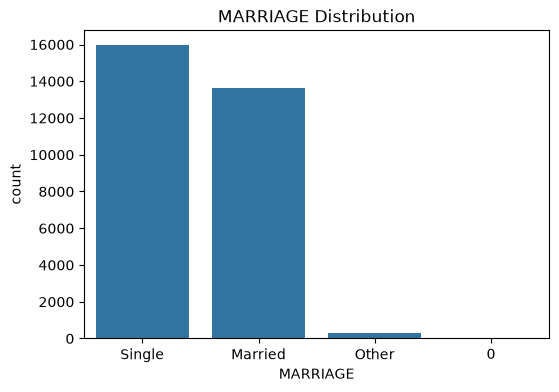

In [21]:
plt.figure(figsize=(6,4))
sns.countplot(x='MARRIAGE', data=df, order=df['MARRIAGE'].value_counts().index)
plt.title('MARRIAGE Distribution')
plt.show()

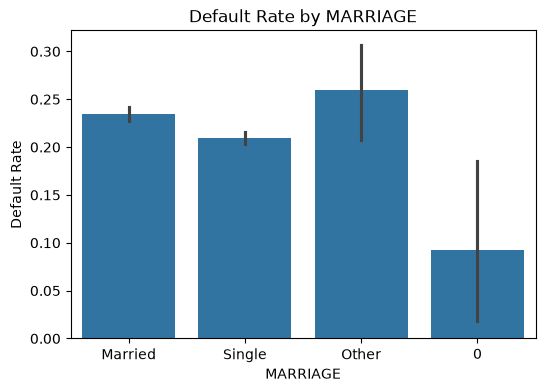

In [22]:
plt.figure(figsize=(6,4))
sns.barplot(x='MARRIAGE', y='default', data=df.assign(default=(df['default']=='Y').astype(int)))
plt.title('Default Rate by MARRIAGE')
plt.ylabel('Default Rate')
plt.show()

### 4. AGE

In [24]:
df['AGE'].describe()

count    30000.000000
mean        35.485500
std          9.217904
min         21.000000
25%         28.000000
50%         34.000000
75%         41.000000
max         79.000000
Name: AGE, dtype: float64

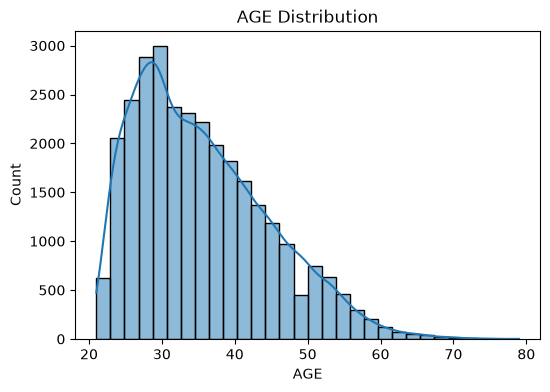

In [25]:
plt.figure(figsize=(6,4))
sns.histplot(df['AGE'], bins=30, kde=True)
plt.title('AGE Distribution')
plt.show()

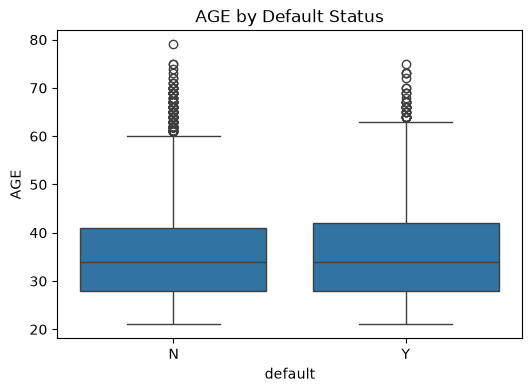

In [26]:
plt.figure(figsize=(6,4))
sns.boxplot(x='default', y='AGE', data=df, order=['N','Y'])
plt.title('AGE by Default Status')
plt.show()

Insight: Most clients are young to middle-aged (25–40), more females than males, mostly University-educated.

In [27]:
df['LIMIT_BAL'].describe()

count      30000.000000
mean      167484.322667
std       129747.661567
min        10000.000000
25%        50000.000000
50%       140000.000000
75%       240000.000000
max      1000000.000000
Name: LIMIT_BAL, dtype: float64

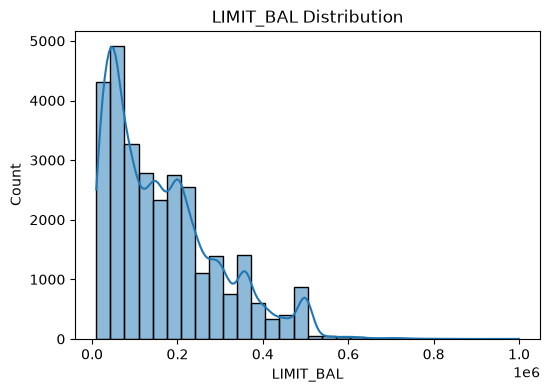

In [28]:
plt.figure(figsize=(6,4))
sns.histplot(df['LIMIT_BAL'], bins=30, kde=True)
plt.title('LIMIT_BAL Distribution')
plt.show()

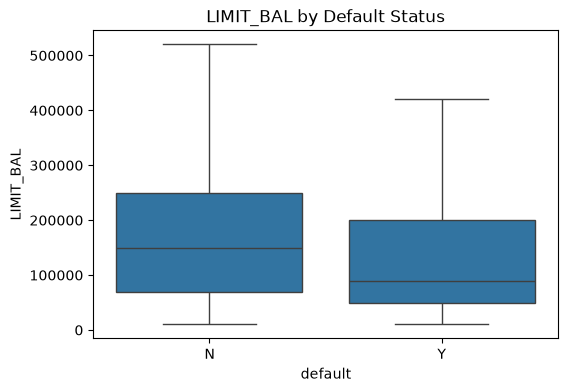

In [29]:
plt.figure(figsize=(6,4))
sns.boxplot(x='default', y='LIMIT_BAL', data=df, order=['N','Y'], showfliers=False)
plt.title('LIMIT_BAL by Default Status')
plt.show()

In [30]:
pay_cols = ['PAY_0', 'PAY_2', 'PAY_3', 'PAY_4', 'PAY_5', 'PAY_6']

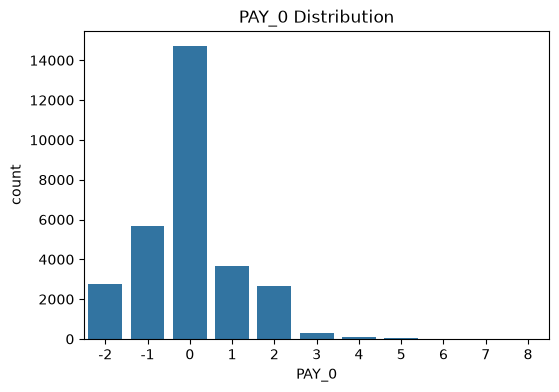

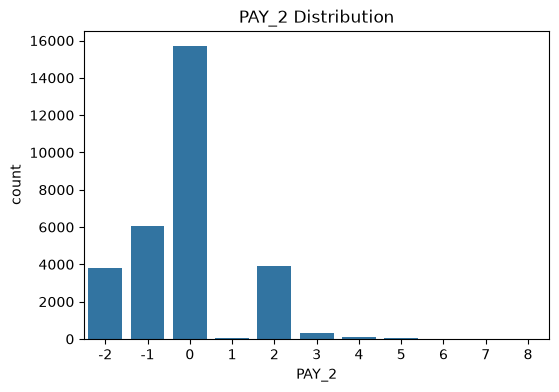

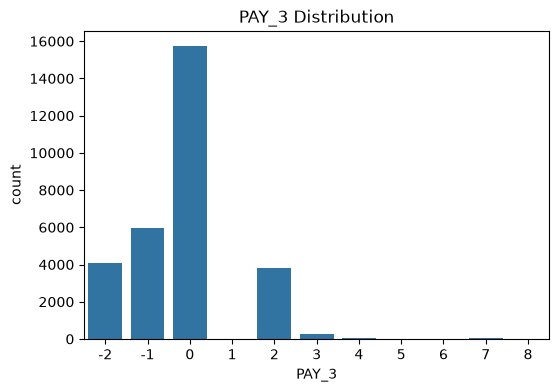

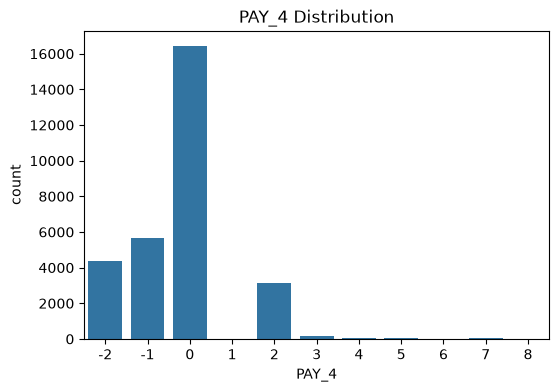

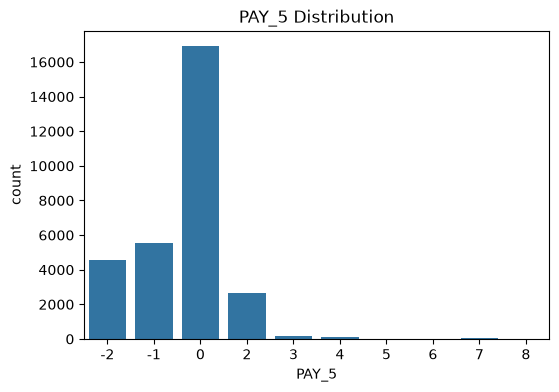

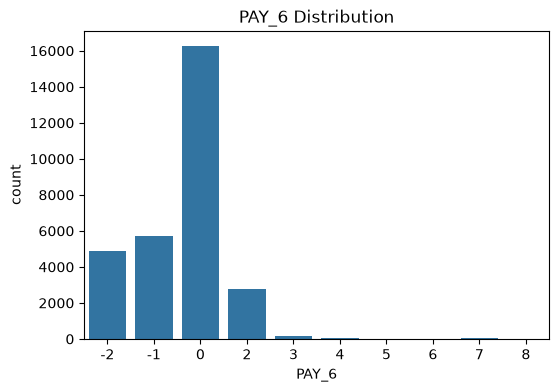

In [31]:
for col in pay_cols:
    plt.figure(figsize=(6,4))
    sns.countplot(x=col, data=df)
    plt.title(col + ' Distribution')
    plt.show()

In [32]:
bill_cols = ['BILL_AMT1', 'BILL_AMT2', 'BILL_AMT3', 'BILL_AMT4', 'BILL_AMT5', 'BILL_AMT6']

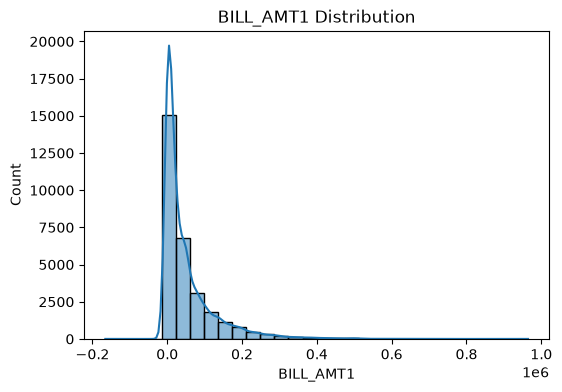

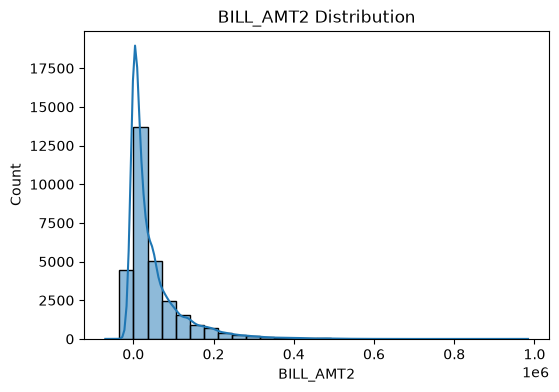

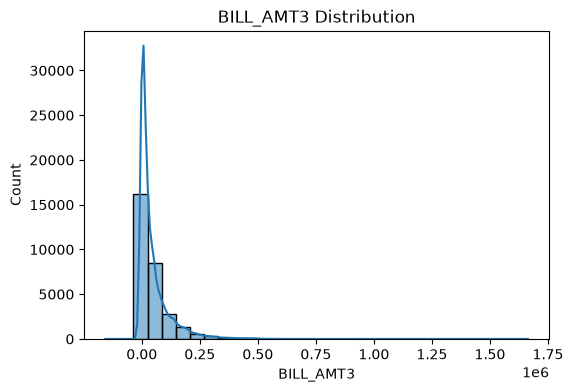

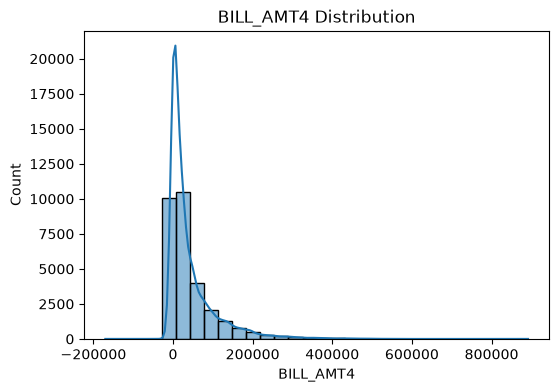

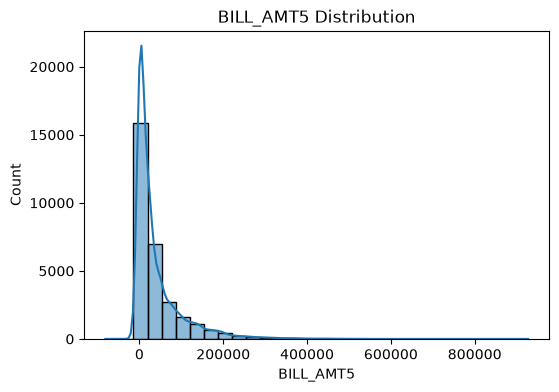

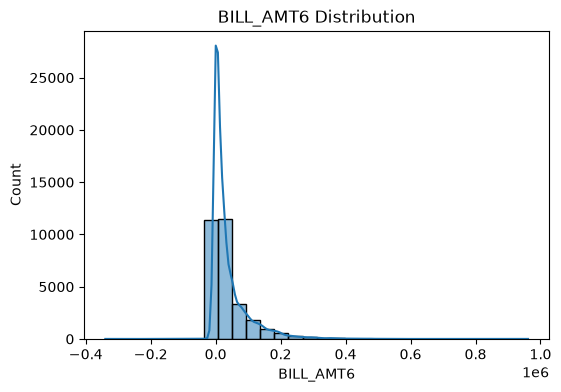

In [33]:
for col in bill_cols:
    plt.figure(figsize=(6,4))
    sns.histplot(df[col], bins=30, kde=True)
    plt.title(col + ' Distribution')
    plt.show()

In [34]:
pay_amt_cols = ['PAY_AMT1', 'PAY_AMT2', 'PAY_AMT3', 'PAY_AMT4', 'PAY_AMT5', 'PAY_AMT6']

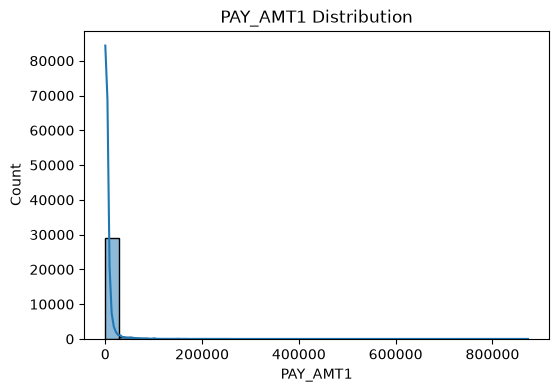

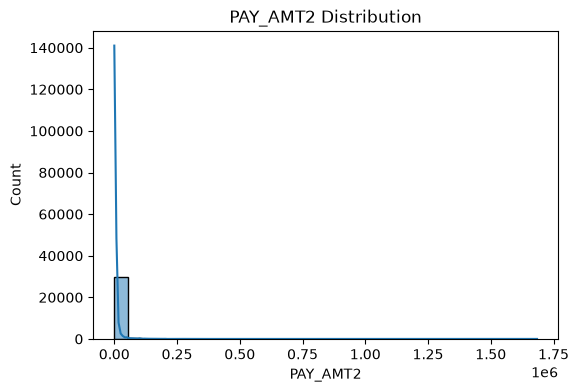

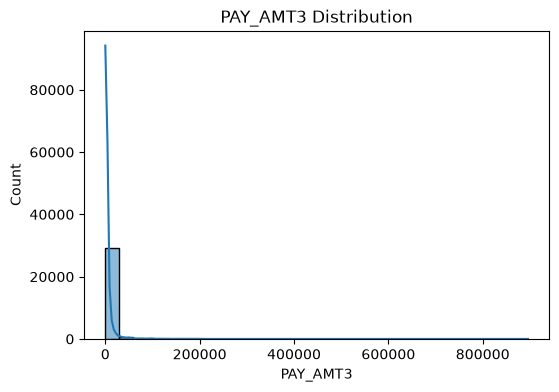

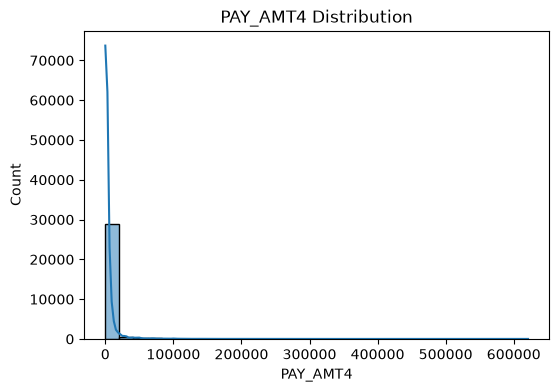

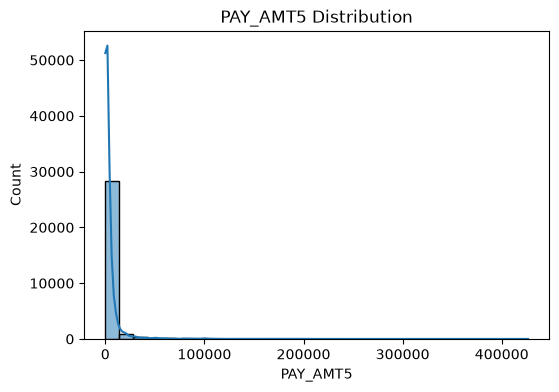

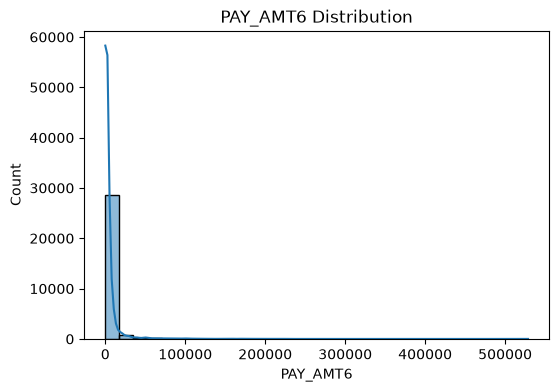

In [35]:
for col in pay_amt_cols:
    plt.figure(figsize=(6,4))
    sns.histplot(df[col], bins=30, kde=True)
    plt.title(col + ' Distribution')
    plt.show()

### Credit limit vs Default

### Repayment Status (PAY_0) vs Default

**Insight:** Clients who default tend to have a lower credit limit on average.

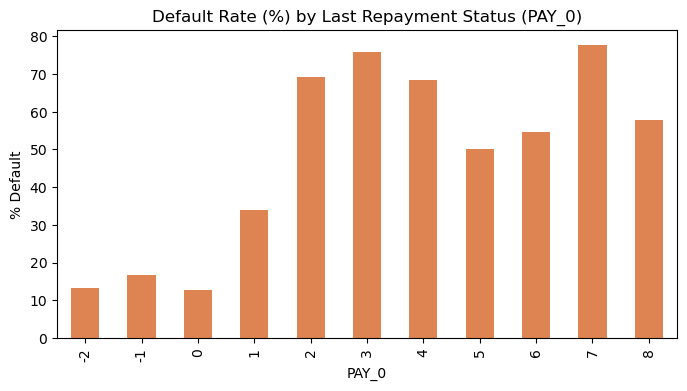

In [21]:
ct = pd.crosstab(df['PAY_0'], df['default'], normalize='index')['Y'] * 100
ct.plot(kind='bar', figsize=(8,4), color='#DD8452')
plt.title('Default Rate (%) by Last Repayment Status (PAY_0)')
plt.ylabel('% Default')
plt.show()

**Insight:** The default rate jumps sharply once a client is 2+ months late on payment — this is the strongest signal in the data.

### Correlation Analysis

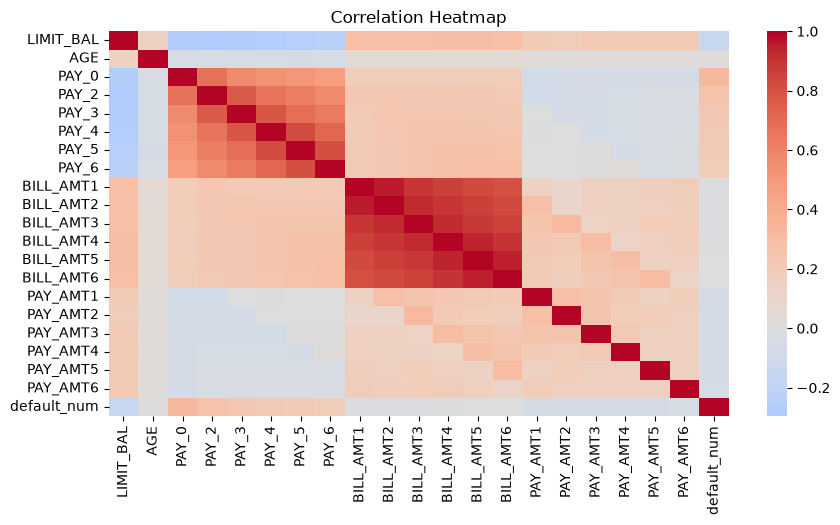

In [43]:
plt.figure(figsize=(10,5))
df_num = df.copy()
df_num['default_num'] = (df_num['default'] == 'Y').astype(int)

all_cols = ['LIMIT_BAL', 'AGE'] + pay_cols + bill_cols + pay_amt_cols + ['default_num']


sns.heatmap(df_num[all_cols].corr(), cmap='coolwarm', center=0)
plt.title('Correlation Heatmap')
plt.show()

- No missing values or duplicate rows — data is clean.
- ~22% of clients defaulted (imbalanced target).
- Lower credit limit → higher chance of default.
- Recent repayment delay (`PAY_0`) is the strongest predictor of default.
- Demographics (age, sex, education) play a smaller role.